# Newton–Schulz Iteration

Newton–Schulz (NS) is an iterative refinement scheme for multivector inverses.  Given
an approximate inverse $X_0 \approx A^{-1}$, each step applies:

$$X_{k+1} = X_k \cdot (2 e_0 - A \cdot X_k)$$

which converges quadratically when $\|e_0 - A X_0\|$ is small.

In practice, the FLS result is already at machine precision for dimensions 6–11.
For dimensions 12–13, accumulated floating-point error in the FLS polynomial means
the raw result has residuals of $O(10^{-3})$; NS then converges to machine precision
in a few iterations.  `euclidean_inverse` does this automatically when `refine=True`.

In [1]:
from clifford.context import Cl
from clifford.multivector import Accum
from clifford.inverse import euclidean_inverse, newton_schulz
import numpy as np
import matplotlib.pyplot as plt

## Manual iteration trace

We reproduce what `euclidean_inverse(refine=True)` does internally: get the raw FLS
result, then pass it to `newton_schulz` as the initial guess.

In [2]:
import clifford.context as ctx
import clifford.sign_table as ST

def residual(A, X):
    """Max-norm residual ||e0 - A*X|| across all blades."""
    r = (A * X).Reg.copy()
    r[0] -= 1.0
    return float(np.max(np.abs(r)))

Cl(12)
A = Accum(); A.random()

X_raw = euclidean_inverse(A, refine=False)
print(f"Raw FLS residual at Cl(12): {residual(A, X_raw):.2e}")

X_refined = newton_schulz(A, X_raw)
print(f"After NS refinement:        {residual(A, X_refined):.2e}")

Raw FLS residual at Cl(12): 1.66e-04
After NS refinement:        1.55e-15


## Convergence plot across dimensions

Raw FLS residual (before NS) vs dimension, showing where refinement becomes necessary.

<>:18: SyntaxWarning: invalid escape sequence '\|'
<>:18: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_29897/3691387246.py:18: SyntaxWarning: invalid escape sequence '\|'
  ax.set_ylabel('Max residual $\|e_0 - A \cdot A^{-1}\|$')


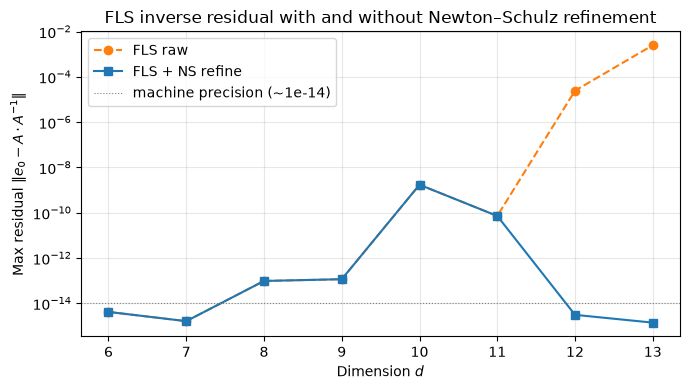

In [3]:
dims = list(range(6, 14))
raw_residuals = []
refined_residuals = []

for d in dims:
    Cl(d)
    A = Accum(); A.random()
    X0 = euclidean_inverse(A, refine=False)
    Xr = euclidean_inverse(A, refine=True)
    raw_residuals.append(residual(A, X0))
    refined_residuals.append(residual(A, Xr))

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(dims, raw_residuals,     'o--', label='FLS raw',         color='tab:orange')
ax.semilogy(dims, refined_residuals, 's-',  label='FLS + NS refine', color='tab:blue')
ax.axhline(1e-14, color='gray', linestyle=':', linewidth=0.8, label='machine precision (~1e-14)')
ax.set_xlabel('Dimension $d$')
ax.set_ylabel('Max residual $\|e_0 - A \cdot A^{-1}\|$')
ax.set_title('FLS inverse residual with and without Newton–Schulz refinement')
ax.set_xticks(dims)
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## NS iteration steps at Cl(13)

Trace the residual at each Newton–Schulz step to show quadratic convergence.

In [4]:
Cl(13)
A = Accum(); A.random()
X0 = euclidean_inverse(A, refine=False)

# Re-implement iteration manually to collect per-step residuals
mul = ctx._ActiveTable.fast_mul
a = A.Reg
x = X0.Reg.copy()
two = np.zeros_like(a); two[0] = 2.0

steps = []
for _ in range(8):
    ax = mul(a, x)
    r = ax.copy(); r[0] -= 1.0
    err = float(np.max(np.abs(r)))
    steps.append(err)
    if err < 1e-14:
        break
    x = mul(x, two - ax)

print("Step  Residual")
for i, r in enumerate(steps):
    print(f"  {i}    {r:.2e}")

Step  Residual
  0    2.02e-04
  1    1.24e-06
  2    2.80e-11
  3    5.11e-15
